# Advanced Energy Consumption Visualizations

This notebook creates three main visualizations:
1. **Total consumption + customer count (dual axis)**
2. **Average consumption over time range**
3. **Daily consumption with customer spread/variability**

In [10]:
# Standard imports
from datasets import load_dataset
import duckdb as ddb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Import your utilities
import utilities.aggregate_customers as agg

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

print("✓ All imports successful")

✓ All imports successful


In [ ]:
# Load dataset
ds = load_dataset("thuml/UTSD", "UTSD-1G")
df = pd.DataFrame(ds['train'])

# Filter for smart meter data
con = ddb.connect()
smart_meter_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%meter%';
""").fetch_df()

print(f"Loaded {len(smart_meter_df)} customer time series")

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

UTSD-12G/data-00008-of-00080.arrow:   0%|          | 0.00/43.6M [00:00<?, ?B/s]

UTSD-12G/data-00002-of-00080.arrow:   0%|          | 0.00/58.1M [00:00<?, ?B/s]

UTSD-12G/data-00004-of-00080.arrow:   0%|          | 0.00/58.1M [00:00<?, ?B/s]

...

UTSD-12G/data-00078-of-00080.arrow:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

UTSD-12G/data-00079-of-00080.arrow:   0%|          | 0.00/438M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 5560 customer time series


## Run Aggregation Pipeline

First, we need to aggregate the data across all customers.

In [22]:
# Run the complete aggregation pipeline
results = agg.complete_aggregation_pipeline(smart_meter_df, freq='30min')

# Extract results
daily_stats = results['daily_stats']
daily_customer_df = results['daily_customer_df']
expanded_df = results['expanded_df']

print(f"\n✓ Aggregation complete!")
print(f"  Daily statistics: {len(daily_stats)} days")
print(f"  Customer-day records: {len(daily_customer_df):,}")


TIME COVERAGE ANALYSIS

Overall date range:
  Earliest start: 2011-11-24 00:00:01
  Latest end: 2014-02-27 23:30:01
  Total span: 826 days

Customer statistics:
  Total customers: 5560
  Mean duration: 623.0 days
  Median duration: 642.0 days
  Min duration: 5 days
  Max duration: 825 days

Start date distribution:
  Earliest: 2011-11-24 00:00:01
  Latest: 2013-10-31 00:00:01

End date distribution:
  Earliest: 2012-05-20 23:30:01
  Latest: 2014-02-27 23:30:01

Expanding time series for 5560 customers...


100%|██████████| 5560/5560 [00:26<00:00, 213.35it/s]


Total data points: 166,528,896
Aggregating to daily level...


MemoryError: Unable to allocate 2.48 GiB for an array with shape (166528896,) and data type complex128

## Visualization 1: Total Consumption + Customer Count (Dual Axis)

Shows total energy consumption across all customers with the number of active customers on a secondary axis.

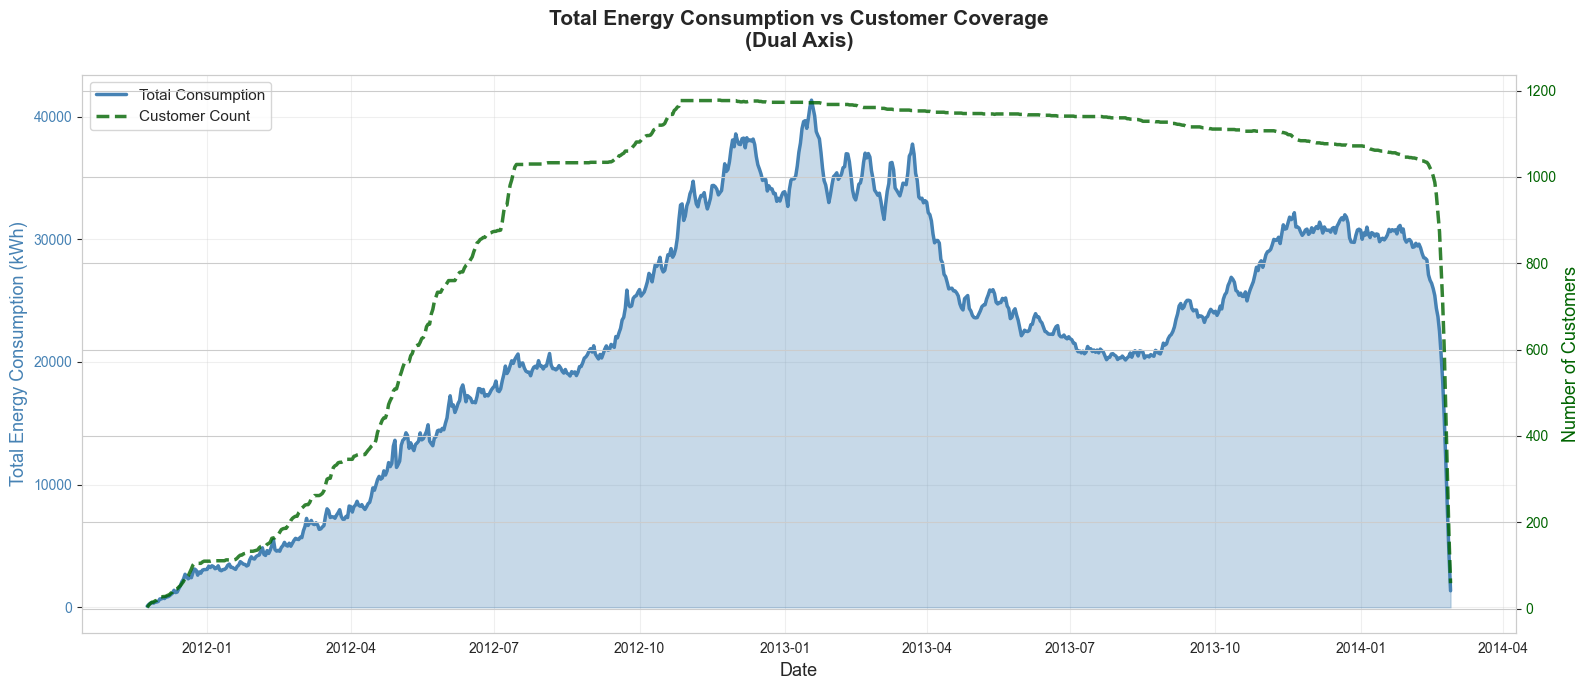

Total consumption statistics:
  Mean daily total: 22,215 kWh
  Peak daily total: 41,342 kWh
  Min daily total: 95 kWh


In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 7))

# Primary axis: Total consumption
color_consumption = 'steelblue'
ax1.set_xlabel('Date', fontsize=13)
ax1.set_ylabel('Total Energy Consumption (kWh)', fontsize=13, color=color_consumption)

line1 = ax1.plot(daily_stats['date'], daily_stats['total_consumption'],
                 color=color_consumption, linewidth=2.5, label='Total Consumption')
ax1.fill_between(daily_stats['date'], daily_stats['total_consumption'],
                 alpha=0.3, color=color_consumption)
ax1.tick_params(axis='y', labelcolor=color_consumption)
ax1.grid(True, alpha=0.3)

# Secondary axis: Customer count
ax2 = ax1.twinx()
color_customers = 'darkgreen'
ax2.set_ylabel('Number of Customers', fontsize=13, color=color_customers)

line2 = ax2.plot(daily_stats['date'], daily_stats['customer_count'],
                 color=color_customers, linewidth=2.5, linestyle='--',
                 label='Customer Count', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_customers)

# Title and legend
plt.title('Total Energy Consumption vs Customer Coverage\n(Dual Axis)',
          fontsize=15, fontweight='bold', pad=20)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Total consumption statistics:")
print(f"  Mean daily total: {daily_stats['total_consumption'].mean():,.0f} kWh")
print(f"  Peak daily total: {daily_stats['total_consumption'].max():,.0f} kWh")
print(f"  Min daily total: {daily_stats['total_consumption'].min():,.0f} kWh")

## Visualization 2: Average Energy Consumption Over Time Range

Shows the average consumption per customer over time, with confidence intervals.

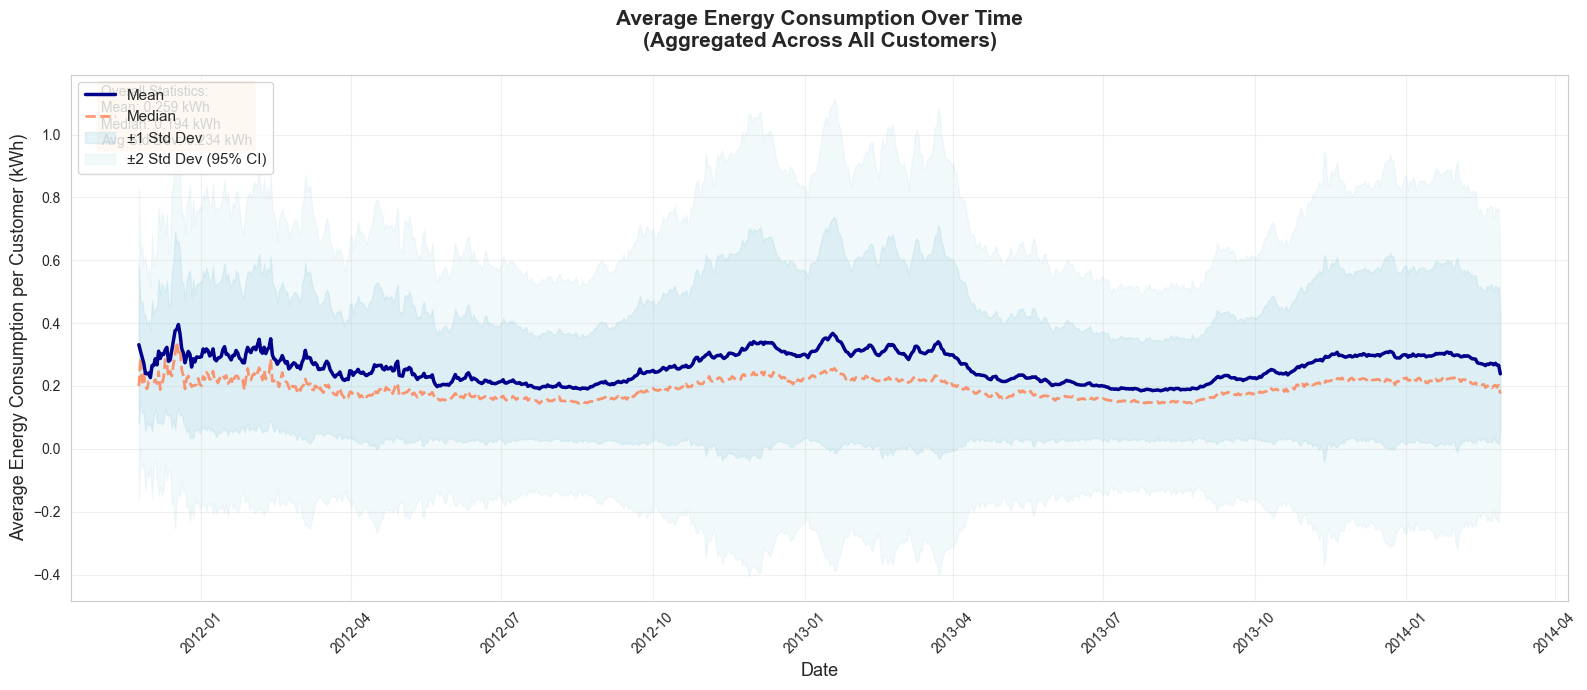

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

# Plot mean consumption
ax.plot(daily_stats['date'], daily_stats['avg_mean_consumption'],
        linewidth=2.5, color='darkblue', label='Mean', zorder=3)

# Plot median consumption
ax.plot(daily_stats['date'], daily_stats['median_mean_consumption'],
        linewidth=2, color='coral', label='Median', alpha=0.8,
        linestyle='--', zorder=2)

# Add confidence bands
ax.fill_between(daily_stats['date'],
                daily_stats['avg_mean_consumption'] - daily_stats['std_mean_consumption'],
                daily_stats['avg_mean_consumption'] + daily_stats['std_mean_consumption'],
                alpha=0.3, color='lightblue', label='±1 Std Dev', zorder=1)

ax.fill_between(daily_stats['date'],
                daily_stats['avg_mean_consumption'] - 2*daily_stats['std_mean_consumption'],
                daily_stats['avg_mean_consumption'] + 2*daily_stats['std_mean_consumption'],
                alpha=0.15, color='lightblue', label='±2 Std Dev (95% CI)', zorder=0)

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Average Energy Consumption per Customer (kWh)', fontsize=13)
ax.set_title('Average Energy Consumption Over Time\n(Aggregated Across All Customers)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# Add statistics box
mean_avg = daily_stats['avg_mean_consumption'].mean()
median_avg = daily_stats['median_mean_consumption'].mean()
std_avg = daily_stats['std_mean_consumption'].mean()

stats_text = f"Overall Statistics:\n"
stats_text += f"Mean: {mean_avg:.3f} kWh\n"
stats_text += f"Median: {median_avg:.3f} kWh\n"
stats_text += f"Avg Std Dev: {std_avg:.3f} kWh"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

## Visualization 3: Daily Average with Customer Spread

### Part A: Box Plot View

Shows the distribution of consumption across customers for sampled dates.

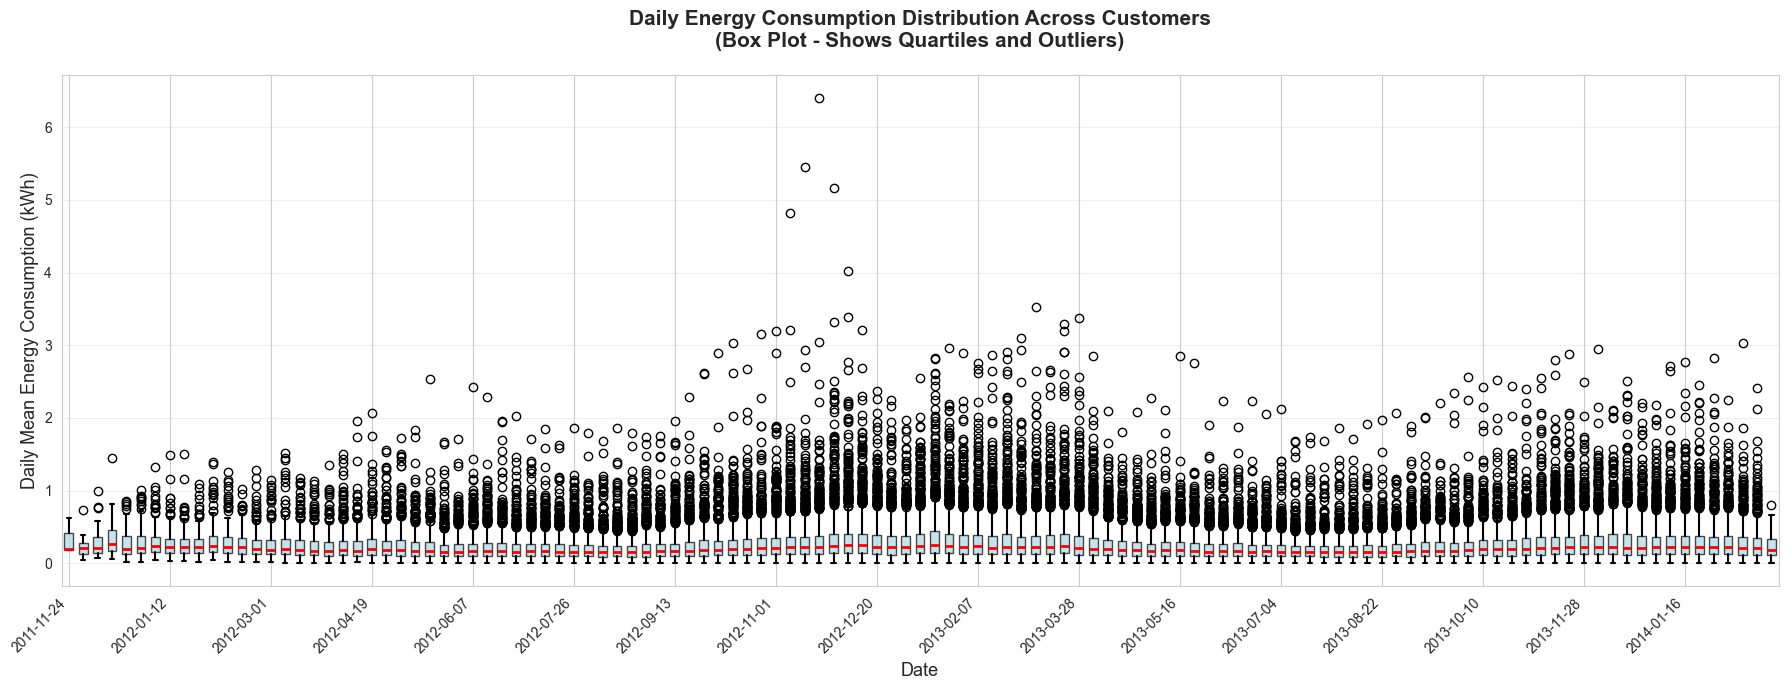

Box plot shows distribution for 119 sampled dates


In [ ]:
# Sample dates for visualization (every 7th day to avoid overcrowding)
dates = sorted(daily_customer_df['date'].unique())
sampled_dates = dates[::7]  # Every 7th day

# Filter data
plot_data = daily_customer_df[daily_customer_df['date'].isin(sampled_dates)].copy()

# Prepare data for box plot
box_data = [plot_data[plot_data['date'] == d]['mean'].values
            for d in sampled_dates]

# Create box plot
fig, ax = plt.subplots(figsize=(18, 7))

positions = range(len(sampled_dates))
bp = ax.boxplot(box_data, positions=positions,
                widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Mean Energy Consumption (kWh)', fontsize=13)
ax.set_title('Daily Energy Consumption Distribution Across Customers\n(Box Plot - Shows Quartiles and Outliers)',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Set x-axis labels
label_step = max(1, len(sampled_dates) // 15)
ax.set_xticks(positions[::label_step])
ax.set_xticklabels([sampled_dates[i].strftime('%Y-%m-%d')
                     for i in range(0, len(sampled_dates), label_step)],
                    rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"Box plot shows distribution for {len(sampled_dates)} sampled dates")

### Part B: Percentile Bands View

Shows continuous percentile bands to visualize spread over time.

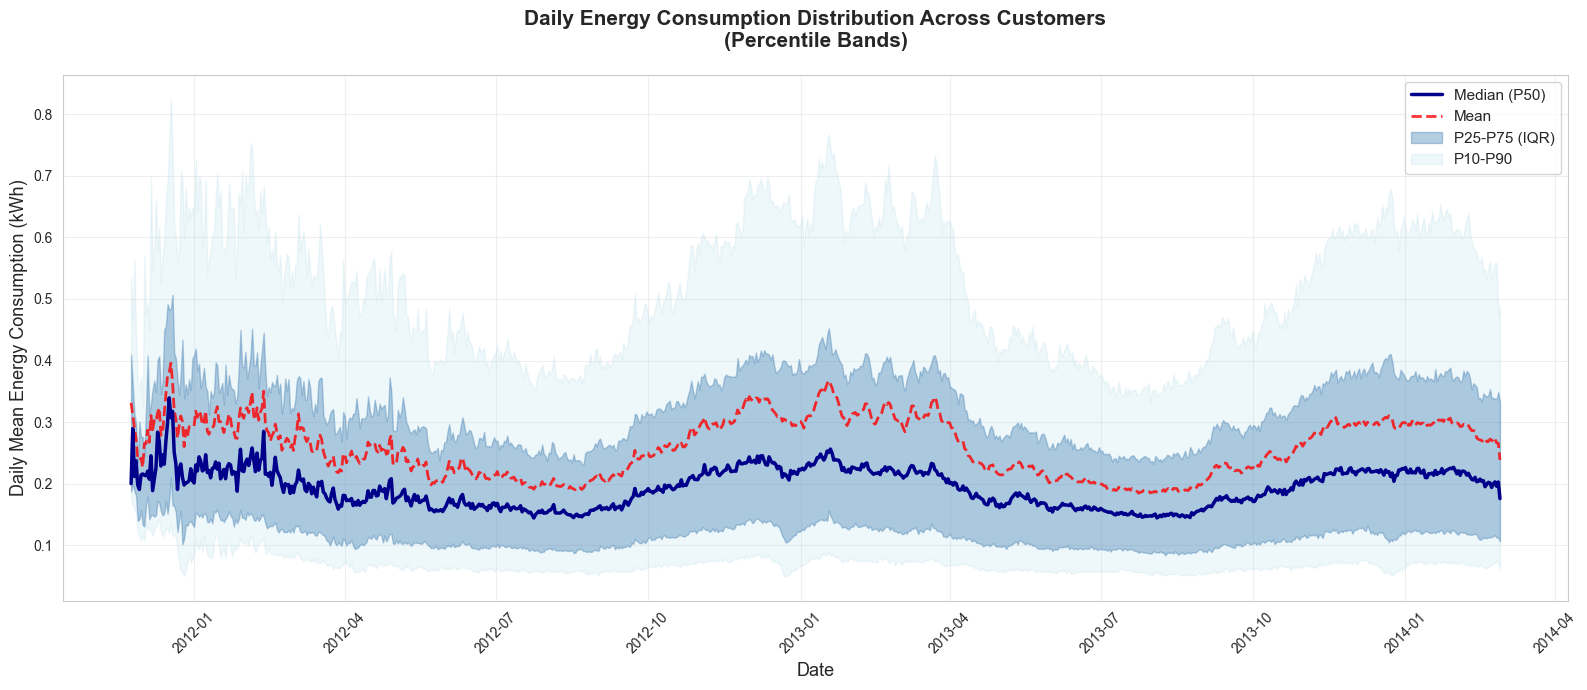


Interpretation:
  - Dark blue band (P25-P75): Middle 50% of customers
  - Light blue band (P10-P90): 80% of customers
  - Median line: Half of customers consume above/below this
  - Mean line: Average across all customers


In [ ]:
# Calculate percentiles for each date
percentile_data = daily_customer_df.groupby('date')['mean'].agg([
    ('p10', lambda x: np.percentile(x, 10)),
    ('p25', lambda x: np.percentile(x, 25)),
    ('p50', lambda x: np.percentile(x, 50)),
    ('p75', lambda x: np.percentile(x, 75)),
    ('p90', lambda x: np.percentile(x, 90)),
    ('mean', 'mean')
]).reset_index()

# Create plot
fig, ax = plt.subplots(figsize=(16, 7))

# Plot median and mean
ax.plot(percentile_data['date'], percentile_data['p50'],
        linewidth=2.5, color='darkblue', label='Median (P50)', zorder=4)
ax.plot(percentile_data['date'], percentile_data['mean'],
        linewidth=2, color='red', label='Mean', linestyle='--',
        alpha=0.8, zorder=3)

# Fill between percentiles
ax.fill_between(percentile_data['date'],
                percentile_data['p25'], percentile_data['p75'],
                alpha=0.4, color='steelblue', label='P25-P75 (IQR)', zorder=2)
ax.fill_between(percentile_data['date'],
                percentile_data['p10'], percentile_data['p90'],
                alpha=0.2, color='lightblue', label='P10-P90', zorder=1)

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Mean Energy Consumption (kWh)', fontsize=13)
ax.set_title('Daily Energy Consumption Distribution Across Customers\n(Percentile Bands)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Dark blue band (P25-P75): Middle 50% of customers")
print("  - Light blue band (P10-P90): 80% of customers")
print("  - Median line: Half of customers consume above/below this")
print("  - Mean line: Average across all customers")

## Bonus: Customer Variability Statistics

In [ ]:
print("=" * 70)
print("CUSTOMER VARIABILITY ANALYSIS")
print("=" * 70)

# Overall statistics
print("\nOverall Daily Average (across all customers and dates):")
print(f"  Mean: {daily_customer_df['mean'].mean():.3f} kWh")
print(f"  Median: {daily_customer_df['mean'].median():.3f} kWh")
print(f"  Std Dev: {daily_customer_df['mean'].std():.3f} kWh")
print(f"  Min: {daily_customer_df['mean'].min():.3f} kWh")
print(f"  Max: {daily_customer_df['mean'].max():.3f} kWh")

# Coefficient of variation (measure of relative variability)
cv = (daily_customer_df['mean'].std() / daily_customer_df['mean'].mean()) * 100
print(f"\nCoefficient of Variation: {cv:.1f}%")

# Per-date variability
date_cv = daily_stats['std_mean_consumption'] / daily_stats['avg_mean_consumption'] * 100
print(f"\nAverage daily variability between customers:")
print(f"  Mean CV: {date_cv.mean():.1f}%")
print(f"  Median CV: {date_cv.median():.1f}%")

# Find most/least variable days
most_variable = daily_stats.loc[date_cv.idxmax()]
least_variable = daily_stats.loc[date_cv.idxmin()]

print(f"\nMost variable day: {most_variable['date'].date()}")
print(f"  CV: {date_cv.max():.1f}%")
print(f"  Mean: {most_variable['avg_mean_consumption']:.3f} kWh")
print(f"  Std: {most_variable['std_mean_consumption']:.3f} kWh")

print(f"\nLeast variable day: {least_variable['date'].date()}")
print(f"  CV: {date_cv.min():.1f}%")
print(f"  Mean: {least_variable['avg_mean_consumption']:.3f} kWh")
print(f"  Std: {least_variable['std_mean_consumption']:.3f} kWh")

print("=" * 70)

CUSTOMER VARIABILITY ANALYSIS

Overall Daily Average (across all customers and dates):
  Mean: 0.256 kWh
  Median: 0.187 kWh
  Std Dev: 0.249 kWh
  Min: 0.000 kWh
  Max: 6.928 kWh

Coefficient of Variation: 97.0%

Average daily variability between customers:
  Mean CV: 89.6%
  Median CV: 89.1%

Most variable day: 2013-11-12
  CV: 114.4%
  Mean: 0.287 kWh
  Std: 0.329 kWh

Least variable day: 2011-11-25
  CV: 49.1%
  Mean: 0.311 kWh
  Std: 0.153 kWh


## Summary

This notebook created:

1. **Dual-axis plot** showing total consumption and customer count
2. **Average consumption plot** with confidence intervals over the full time range
3. **Customer spread visualizations**:
   - Box plots showing quartiles and outliers
   - Percentile bands showing distribution over time
4. **Statistical analysis** of variability across customers